# B-6511502A — Detecção de Anomalia via CUSUM + Persistence Filter

Aplica CUSUM sobre o score de reconstrução do melhor modelo AutoML — **sem retreinamento**.
O artifact `best_full_scores` já está salvo no ClearML; suavização, CUSUM e persistence filter são pós-processamento puro.

**Pipeline:**
```
score bruto (ClearML) → rolling median (suavização) → CUSUM → persistence filter (K de N) → alertas
```

**Por que suavizar primeiro?**  
Spikes isolados não mudam a mediana de uma janela — mas uma elevação sustentada sim.  
O CUSUM no sinal suavizado detecta regimes, não ruído.

**Por que persistence filter depois do CUSUM?**  
O CUSUM pode cruzar o limiar `h` em bursts isolados (ex.: 1–2 pontos consecutivos) que não representam anomalia real.  
O persistence filter exige que `K` dos últimos `N` pontos sejam alarme — mata bursts, preserva elevação sustentada.

**Fórmula CUSUM upper-sided:**
```
S_t = max(0, S_{t-1} + (x_t - μ₀)/σ - k)
alerta_cusum quando S_t > h
```
**Persistence filter:**
```
alerta_final[t] = 1  se  sum(alerta_cusum[t-N+1 : t+1]) >= K
```
- `μ₀`, `σ` — calculados no período normal (referência)
- `k` — slack: ignora desvios < k·σ acima de μ₀
- `h` — decisão: acumulado precisa superar h para gerar alerta CUSUM
- `K`, `N` — persistence: K alarmes CUSUM dentro de janela de N amostras

**Equipamento:** B-6511502A  
**Falha:** 15/Mai/2023 — Quebra das lâminas do acoplamento  
**Task AutoML:** `5228c1f4f16a4a84bf11c0c1749f9530`

In [23]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists()),
    Path.cwd(),
)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

In [24]:
# ==============================
# Configuracao
# ==============================
AUTOML_TASK_ID = '5228c1f4f16a4a84bf11c0c1749f9530'
EQUIPMENT_ID   = 'B-6511502A'

EVENT_DATE  = '2023-05-15 00:00'
EVENT_LABEL = 'Falha (15/Mai/2023)'
EVENT_TS    = pd.Timestamp(EVENT_DATE)

# Janela de referencia (normal) para calcular μ₀ e σ
REF_START = '2022-09-01'
REF_END   = '2023-04-15'   # 30 dias antes da falha

# Janelas de metricas
PREFAILURE_DAYS = 14
NORMAL_END_DAYS = 30

# --- Suavizacao ---
# Metodo: 'median' | 'mean' | 'ewm'
# Janela em amostras (assumindo ~5min/amostra: 12 = 1h, 24 = 2h, 72 = 6h)
SMOOTH_METHOD = 'median'
SMOOTH_WINDOW = 12   # amostras

# --- CUSUM (parametros iniciais; grid abaixo otimiza automaticamente) ---
CUSUM_K         = 1.0    # slack em sigmas
CUSUM_H         = 5.0    # decisao em sigmas
RESET_ON_ALARM  = True

# --- Persistence filter (aplicado sobre alarmes CUSUM) ---
# Requer PERSIST_K alarmes dentro de janela de PERSIST_N amostras (janela trailing/causal)
# (1, 1) = sem filtro  |  (2, 3) = 2 de 3  |  (3, 5) = 3 de 5  |  (5, 10) = 5 de 10
PERSIST_K = 2   # numero minimo de alarmes na janela
PERSIST_N = 3   # tamanho da janela

# --- Constraint do grid: so aceita configuracoes com normal_rate abaixo desse limite ---
MAX_NORMAL_RATE = 0.03   # 3%

FIGSIZE_WIDTH = 14
OUTPUT_DPI    = 160

In [25]:
# --- Carrega scores ---
task = Task.get_task(task_id=AUTOML_TASK_ID)
scores_raw = task.artifacts['best_full_scores'].get()

scores = scores_raw.copy()
scores.index = pd.to_datetime(scores.index)
scores = scores.sort_index()

x_raw = scores['reconstruction_error'].values.astype('float64')
ts    = scores.index

# --- Suavizacao ---
s = pd.Series(x_raw, index=ts)
if SMOOTH_METHOD == 'median':
    x = s.rolling(window=SMOOTH_WINDOW, min_periods=1, center=True).median().values
elif SMOOTH_METHOD == 'mean':
    x = s.rolling(window=SMOOTH_WINDOW, min_periods=1, center=True).mean().values
elif SMOOTH_METHOD == 'ewm':
    x = s.ewm(span=SMOOTH_WINDOW).mean().values
else:
    x = x_raw.copy()

# --- Estatisticas do periodo de referencia (calculadas no sinal suavizado) ---
ref_mask = (ts >= pd.Timestamp(REF_START)) & (ts < pd.Timestamp(REF_END))
x_ref    = x[ref_mask]
mu0      = float(np.mean(x_ref))
sigma    = float(np.std(x_ref, ddof=1))

print(f'Amostras:    {len(ts)}  ({ts.min()} → {ts.max()})')
print(f'Suavizacao:  {SMOOTH_METHOD}  janela={SMOOTH_WINDOW} amostras')
print(f'Referencia:  {REF_START} → {REF_END}  (n={ref_mask.sum()})')
print(f'μ₀={mu0:.5f}   σ={sigma:.5f}')

Amostras:    36364  (2022-05-22 13:40:00 → 2023-05-13 14:35:00)
Suavizacao:  median  janela=12 amostras
Referencia:  2022-09-01 → 2023-04-15  (n=27434)
μ₀=0.12724   σ=0.14104


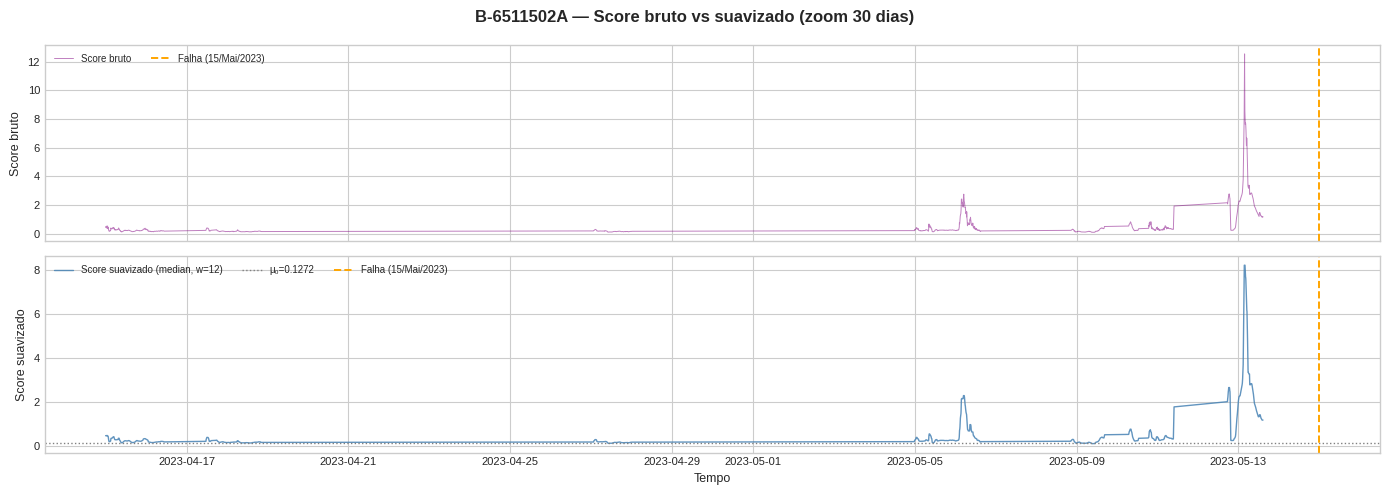

In [26]:
# --- Visualiza efeito da suavizacao ---
plt.style.use('seaborn-v0_8-whitegrid')
zoom_start = EVENT_TS - pd.Timedelta(days=30)
zm = (ts >= zoom_start) & (ts <= EVENT_TS)

fig, axes = plt.subplots(2, 1, figsize=(FIGSIZE_WIDTH, 5), sharex=True)

axes[0].plot(ts[zm], x_raw[zm], color='purple', linewidth=0.7, alpha=0.5, label='Score bruto')
axes[0].axvline(EVENT_TS, color='orange', linestyle='--', linewidth=1.4, label=EVENT_LABEL)
axes[0].set_ylabel('Score bruto', fontsize=9)
axes[0].legend(fontsize=7, ncol=2)
axes[0].tick_params(labelsize=8)

axes[1].plot(ts[zm], x[zm], color='steelblue', linewidth=1.0, alpha=0.85,
             label=f'Score suavizado ({SMOOTH_METHOD}, w={SMOOTH_WINDOW})')
axes[1].axhline(mu0, color='gray', linestyle=':', linewidth=1.0, label=f'μ₀={mu0:.4f}')
axes[1].axvline(EVENT_TS, color='orange', linestyle='--', linewidth=1.4, label=EVENT_LABEL)
axes[1].set_ylabel('Score suavizado', fontsize=9)
axes[1].set_xlabel('Tempo', fontsize=9)
axes[1].legend(fontsize=7, ncol=3)
axes[1].tick_params(labelsize=8)

fig.suptitle(f'{EQUIPMENT_ID} — Score bruto vs suavizado (zoom 30 dias)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

In [27]:
def cusum_upper(x: np.ndarray, mu0: float, sigma: float,
                k: float, h: float,
                reset_on_alarm: bool = True) -> tuple[np.ndarray, np.ndarray]:
    n = len(x)
    S = np.zeros(n)
    alarms = np.zeros(n, dtype=bool)
    s = 0.0
    for i in range(n):
        xi_norm = (x[i] - mu0) / sigma if sigma > 0 else 0.0
        s = max(0.0, s + xi_norm - k)
        S[i] = s
        if s > h:
            alarms[i] = True
            if reset_on_alarm:
                s = 0.0
    return S, alarms


def persistence_filter(alarms: np.ndarray, pk: int, pn: int) -> np.ndarray:
    """Requer pk alarmes dentro de janela trailing de pn amostras.
    (1, 1) = sem filtro; (2, 3) = 2 de 3; (3, 5) = 3 de 5."""
    if pk <= 1 and pn <= 1:
        return alarms.copy()
    n = len(alarms)
    result = np.zeros(n, dtype=bool)
    # Usa convolucao para eficiencia: soma movel de janela pn
    cumsum = np.cumsum(alarms.astype(int))
    window_sum = cumsum.copy()
    window_sum[pn:] = cumsum[pn:] - cumsum[:-pn]
    result = window_sum >= pk
    return result


def failure_metrics(alarms: np.ndarray, ts: pd.DatetimeIndex,
                    event_ts: pd.Timestamp,
                    prefailure_days: int, normal_end_days: int) -> dict:
    normal_end = event_ts - pd.Timedelta(days=normal_end_days)
    pf_start   = event_ts - pd.Timedelta(days=prefailure_days)
    normal_mask = ts < normal_end
    pf_mask     = (ts >= pf_start) & (ts < event_ts)
    normal_rate = float(alarms[normal_mask].mean()) if normal_mask.sum() > 0 else 0.0
    pf_rate     = float(alarms[pf_mask].mean())     if pf_mask.sum() > 0 else 0.0
    return {
        'composite_score':       pf_rate * (1.0 - normal_rate),
        'prefailure_alert_rate': pf_rate,
        'normal_alert_rate':     normal_rate,
        'discrimination_ratio':  pf_rate / (normal_rate + 1e-9),
        'n_alarms_total':        int(alarms.sum()),
    }


def plot_cusum(ts, x_smooth, S, alarms, alarms_filtered, h, mu0, sigma,
               event_ts, event_label, title, k, pk, pn, figsize_width=14, dpi=160):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 1, figsize=(figsize_width, 6), sharex=True,
                              gridspec_kw={'height_ratios': [1, 1.2]})

    ax0 = axes[0]
    ax0.plot(ts, x_smooth, color='steelblue', linewidth=0.9, alpha=0.8, label='Score suavizado')
    ax0.axhline(mu0, color='gray', linestyle=':', linewidth=1.0, label=f'μ₀={mu0:.4f}')
    ax0.axhline(mu0 + sigma, color='slategray', linestyle=':', linewidth=0.7, label='μ₀+σ')
    # Alarmes CUSUM brutos (cinza, fundo)
    cusum_only = alarms & ~alarms_filtered
    if cusum_only.sum() > 0:
        ax0.scatter(ts[cusum_only], x_smooth[cusum_only], s=18, color='lightcoral',
                    edgecolor='none', alpha=0.5, zorder=3, label=f'CUSUM (filtrado out)')
    # Alarmes finais (persistidos)
    if alarms_filtered.sum() > 0:
        ax0.scatter(ts[alarms_filtered], x_smooth[alarms_filtered], s=30, color='red',
                    edgecolor='none', alpha=0.9, zorder=4,
                    label=f'Alertas finais ({alarms_filtered.sum()}, persist {pk}/{pn})')
    ax0.axvline(event_ts, color='orange', linestyle='--', linewidth=1.5, label=event_label)
    ax0.set_ylabel('Score suavizado', fontsize=9)
    ax0.legend(loc='upper left', fontsize=7, ncol=4, frameon=True)
    ax0.tick_params(labelsize=8)

    ax1 = axes[1]
    ax1.plot(ts, S, color='steelblue', linewidth=0.9, alpha=0.8, label='Acumulador S_t')
    ax1.axhline(h, color='red', linestyle='--', linewidth=1.3, label=f'Limite h={h:.1f}σ')
    ax1.fill_between(ts, h, S, where=(S > h), color='red', alpha=0.20)
    ax1.axvline(event_ts, color='orange', linestyle='--', linewidth=1.5, label=event_label)
    ax1.set_ylabel('S_t (acumulado, em σ)', fontsize=9)
    ax1.set_xlabel('Tempo', fontsize=9)
    ax1.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
    ax1.tick_params(labelsize=8)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

## Grid search k × h × persistence com restrição de falso positivo

Grid 3D: `k` (slack CUSUM) × `h` (decisão CUSUM) × `(pk, pn)` (persistence filter).  
Só aceita combinações onde `normal_alert_rate ≤ MAX_NORMAL_RATE` (configurável).  
Dentro dessas, maximiza `composite_score`.

**Combos de persistence testados:**
- `(1, 1)` — sem filtro (CUSUM puro)
- `(2, 3)` — 2 de 3 amostras consecutivas
- `(3, 5)` — 3 de 5 amostras consecutivas
- `(3, 10)` — 3 de 10 amostras (~50 min de alarme sustentado)
- `(5, 10)` — 5 de 10 amostras (maioria)

In [28]:
K_GRID = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]
H_GRID = [1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 30.0, 50.0]
PERSIST_COMBOS = [(1, 1), (2, 3), (3, 5), (3, 10), (5, 10)]

rows = []
for k in K_GRID:
    for h in H_GRID:
        S_, al_cusum = cusum_upper(x, mu0, sigma, k=k, h=h, reset_on_alarm=RESET_ON_ALARM)
        for pk, pn in PERSIST_COMBOS:
            al_ = persistence_filter(al_cusum, pk, pn)
            m = failure_metrics(al_, ts, EVENT_TS, PREFAILURE_DAYS, NORMAL_END_DAYS)
            rows.append({'k': k, 'h': h, 'persist_k': pk, 'persist_n': pn, **m})

grid_df = pd.DataFrame(rows)

n_total = len(K_GRID) * len(H_GRID) * len(PERSIST_COMBOS)
print(f'Combinacoes testadas: {n_total}  ({len(K_GRID)}k × {len(H_GRID)}h × {len(PERSIST_COMBOS)} persist)')

# Aplica constraint e ordena
grid_constrained = grid_df[grid_df['normal_alert_rate'] <= MAX_NORMAL_RATE].copy()

if len(grid_constrained) == 0:
    print(f'[AVISO] Nenhuma configuracao com normal_rate <= {MAX_NORMAL_RATE:.0%}. '
          'Aumente MAX_NORMAL_RATE ou ajuste SMOOTH_WINDOW.')
    grid_best = grid_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
else:
    grid_best = grid_constrained.sort_values('composite_score', ascending=False).reset_index(drop=True)
    print(f'Validas (normal_rate <= {MAX_NORMAL_RATE:.0%}): {len(grid_constrained)} de {n_total}')

fmt = {
    'composite_score': '{:.4f}',
    'prefailure_alert_rate': '{:.2%}',
    'normal_alert_rate': '{:.2%}',
    'discrimination_ratio': '{:.1f}',
}
print('\nTop 15 (com constraint):')
display(grid_best.head(15).style.format(fmt).background_gradient(subset=['composite_score'], cmap='Greens'))

Combinacoes testadas: 360  (8k × 9h × 5 persist)
Validas (normal_rate <= 3%): 344 de 360

Top 15 (com constraint):


,k,h,persist_k,persist_n,composite_score,prefailure_alert_rate,normal_alert_rate,discrimination_ratio,n_alarms_total
0,0.750000,1.000000,1,1,0.4785,49.30%,2.95%,16.7,1697
1,0.750000,2.000000,3,10,0.4738,48.81%,2.94%,16.6,1685
2,0.500000,3.000000,3,10,0.4718,48.56%,2.85%,17.0,1647
3,0.750000,1.000000,5,10,0.4690,48.32%,2.94%,16.5,1677
4,0.250000,2.000000,5,10,0.4653,47.91%,2.87%,16.7,1647
5,0.500000,2.000000,1,1,0.4458,45.78%,2.60%,17.6,1523
6,0.750000,1.000000,3,5,0.4433,45.53%,2.64%,17.2,1527
7,0.750000,1.000000,2,3,0.4424,45.45%,2.66%,17.1,1534
8,0.250000,3.000000,1,1,0.4343,44.54%,2.50%,17.8,1490
9,1.000000,1.000000,5,10,0.4282,43.89%,2.44%,18.0,1422


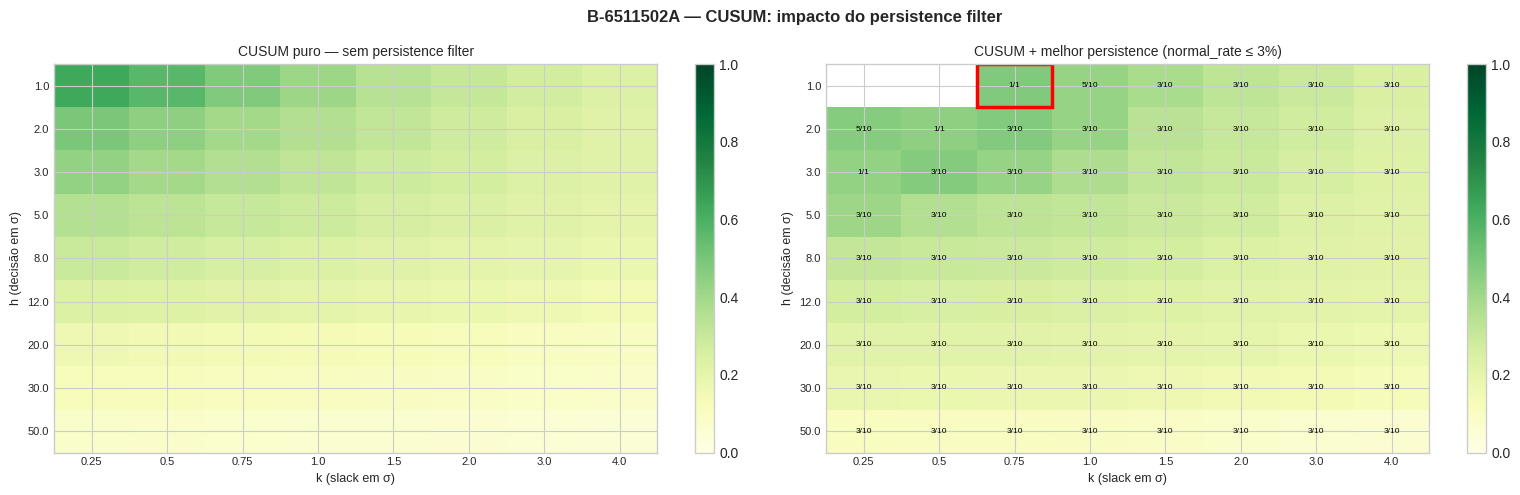

Melhor: k=0.75  h=1.0  persist=1/1  composite=0.4785  prefailure=49.30%  normal=2.95%


In [29]:
# Heatmap: melhor composite_score por k×h (marginalizando sobre combos de persistence)
# Para cada (k,h), pega a melhor combo persist dentro do constraint
best_per_kh = (
    grid_constrained
    .sort_values('composite_score', ascending=False)
    .groupby(['k', 'h'], sort=False)
    .first()
    .reset_index()
) if len(grid_constrained) > 0 else grid_df.groupby(['k', 'h']).first().reset_index()

pivot_best = best_per_kh.pivot(index='h', columns='k', values='composite_score')
pivot_persist = best_per_kh.pivot(index='h', columns='k', values='persist_k').astype('Int64').astype(str) \
    + '/' + best_per_kh.pivot(index='h', columns='k', values='persist_n').astype('Int64').astype(str)

# Pivot sem constraint (CUSUM puro, persist (1,1)) para referencia
pivot_nocusum = (
    grid_df[grid_df['persist_k'] == 1]
    .pivot(index='h', columns='k', values='composite_score')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title_ in [
    (axes[0], pivot_nocusum, 'CUSUM puro — sem persistence filter'),
    (axes[1], pivot_best,    f'CUSUM + melhor persistence (normal_rate ≤ {MAX_NORMAL_RATE:.0%})'),
]:
    im = ax.imshow(data.values, aspect='auto', cmap='YlGn', origin='upper', vmin=0, vmax=1)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels([f'{v}' for v in data.columns], fontsize=8)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels([f'{v}' for v in data.index], fontsize=8)
    ax.set_xlabel('k (slack em σ)', fontsize=9)
    ax.set_ylabel('h (decisão em σ)', fontsize=9)
    ax.set_title(title_, fontsize=10)
    plt.colorbar(im, ax=ax)

# Anota o melhor persist em cada célula do heatmap direito
for i, h_val in enumerate(pivot_best.index):
    for j, k_val in enumerate(pivot_best.columns):
        lbl = pivot_persist.loc[h_val, k_val] if h_val in pivot_persist.index and k_val in pivot_persist.columns else ''
        if str(lbl) not in ('nan', '<NA>/<NA>', ''):
            axes[1].text(j, i, str(lbl), ha='center', va='center', fontsize=6, color='black')

# Marca o melhor global
if len(grid_best) > 0:
    best = grid_best.iloc[0]
    try:
        bi = list(pivot_best.index).index(best['h'])
        bj = list(pivot_best.columns).index(best['k'])
        axes[1].add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1,
                         fill=False, edgecolor='red', linewidth=2.5))
    except ValueError:
        pass

fig.suptitle(f'{EQUIPMENT_ID} — CUSUM: impacto do persistence filter', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

best = grid_best.iloc[0]
print(f'Melhor: k={best["k"]}  h={best["h"]}  persist={int(best["persist_k"])}/{int(best["persist_n"])}'
      f'  composite={best["composite_score"]:.4f}'
      f'  prefailure={best["prefailure_alert_rate"]:.2%}  normal={best["normal_alert_rate"]:.2%}')

## Melhor configuração — visualização

CUSUM otimizado: k=0.75σ  h=1.0σ  persist=1/1  smooth=median(w=12)
  composite_score:       0.4785
  prefailure_alert_rate: 49.30%
  normal_alert_rate:     2.95%
  discrimination_ratio:  16.69
  alertas totais:        1697  (CUSUM bruto: 1697  →  após persist: 1697)


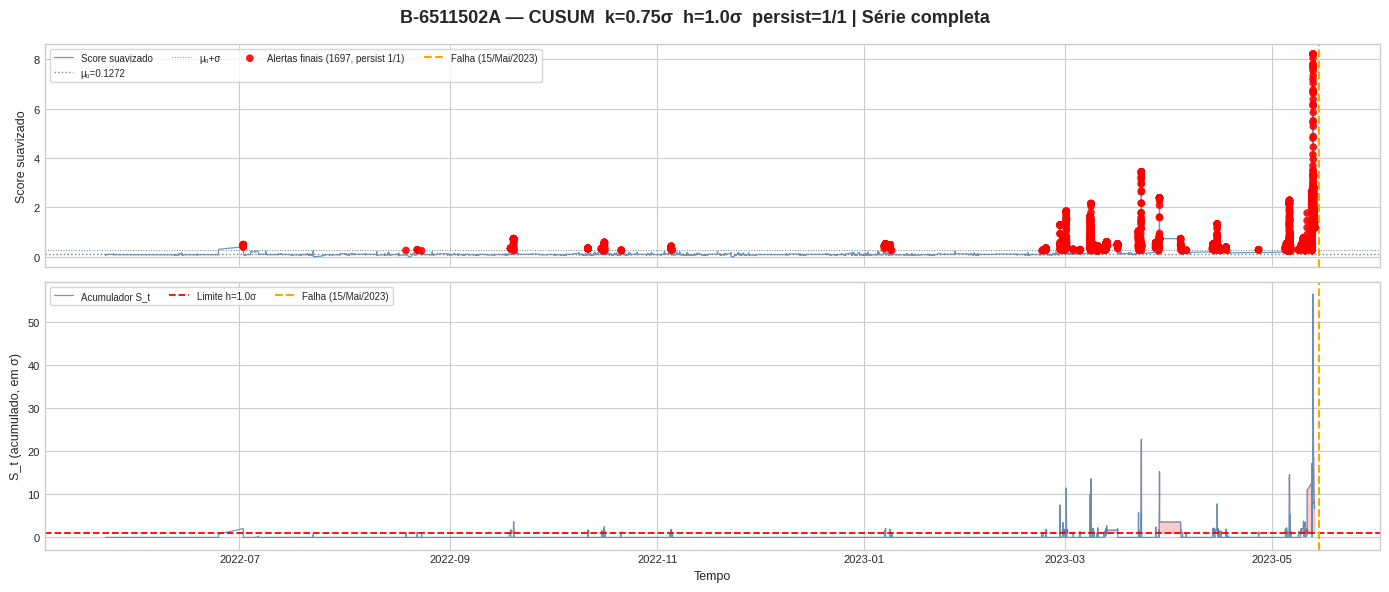

In [30]:
BEST_K  = float(grid_best.iloc[0]['k'])
BEST_H  = float(grid_best.iloc[0]['h'])
BEST_PK = int(grid_best.iloc[0]['persist_k'])
BEST_PN = int(grid_best.iloc[0]['persist_n'])

S_best, alarms_cusum = cusum_upper(x, mu0, sigma, k=BEST_K, h=BEST_H, reset_on_alarm=RESET_ON_ALARM)
alarms_best = persistence_filter(alarms_cusum, BEST_PK, BEST_PN)
m_best = failure_metrics(alarms_best, ts, EVENT_TS, PREFAILURE_DAYS, NORMAL_END_DAYS)

print(f'CUSUM otimizado: k={BEST_K}σ  h={BEST_H}σ  persist={BEST_PK}/{BEST_PN}'
      f'  smooth={SMOOTH_METHOD}(w={SMOOTH_WINDOW})')
print(f'  composite_score:       {m_best["composite_score"]:.4f}')
print(f'  prefailure_alert_rate: {m_best["prefailure_alert_rate"]:.2%}')
print(f'  normal_alert_rate:     {m_best["normal_alert_rate"]:.2%}')
print(f'  discrimination_ratio:  {m_best["discrimination_ratio"]:.2f}')
print(f'  alertas totais:        {m_best["n_alarms_total"]}  '
      f'(CUSUM bruto: {int(alarms_cusum.sum())}  →  após persist: {int(alarms_best.sum())})')

# Serie completa
plot_cusum(
    ts, x, S_best, alarms_cusum, alarms_best,
    h=BEST_H, mu0=mu0, sigma=sigma,
    event_ts=EVENT_TS, event_label=EVENT_LABEL,
    title=f'{EQUIPMENT_ID} — CUSUM  k={BEST_K}σ  h={BEST_H}σ  persist={BEST_PK}/{BEST_PN} | Série completa',
    k=BEST_K, pk=BEST_PK, pn=BEST_PN, figsize_width=FIGSIZE_WIDTH, dpi=OUTPUT_DPI,
)

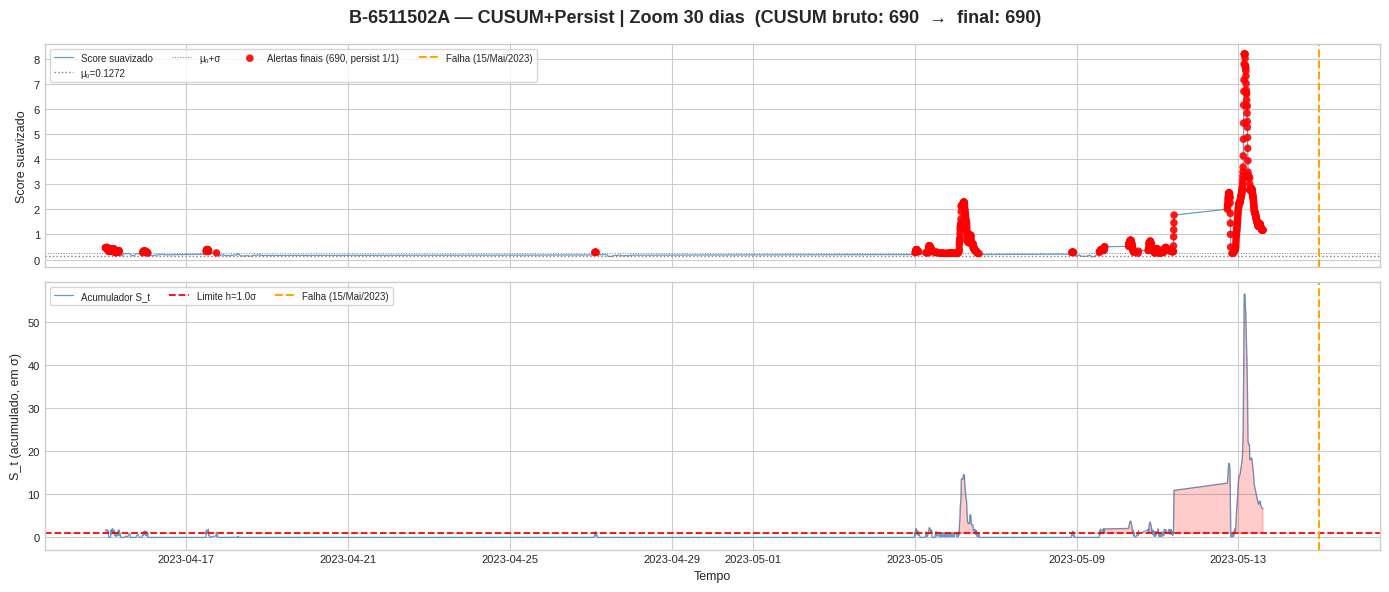

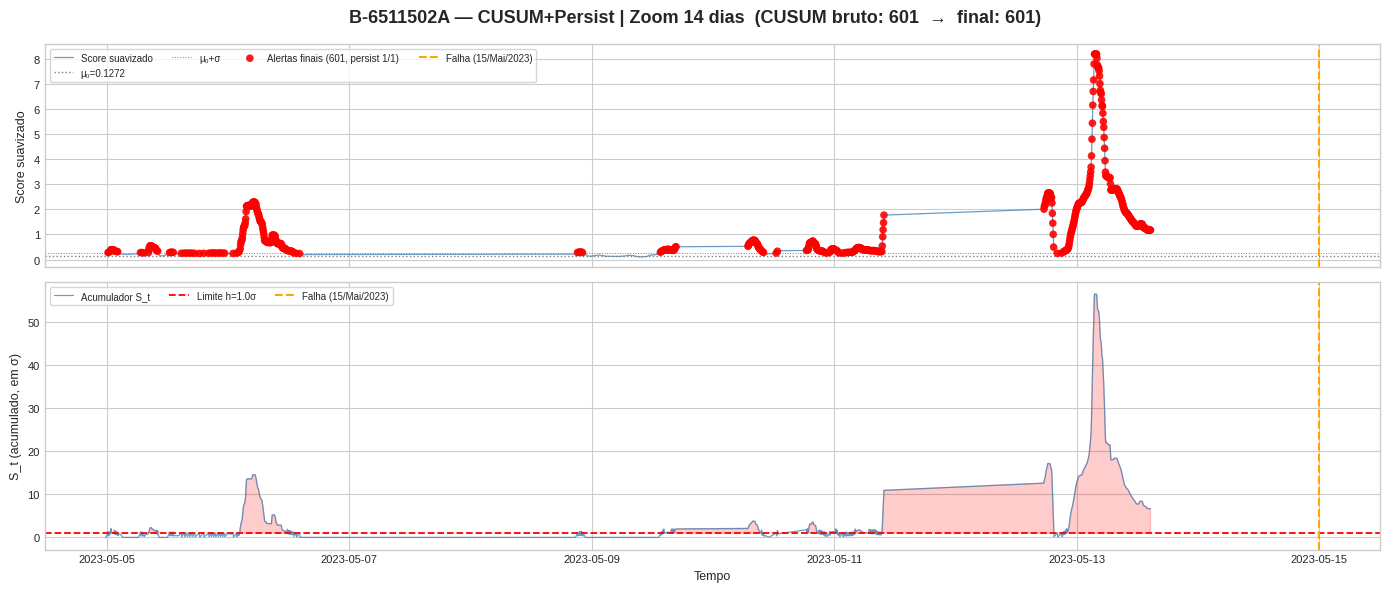

In [31]:
# Zoom 30 e 14 dias
for zoom_days in [30, 14]:
    zm = (ts >= EVENT_TS - pd.Timedelta(days=zoom_days)) & (ts <= EVENT_TS)
    n_final = int(alarms_best[zm].sum())
    n_cusum = int(alarms_cusum[zm].sum())
    plot_cusum(
        ts[zm], x[zm], S_best[zm], alarms_cusum[zm], alarms_best[zm],
        h=BEST_H, mu0=mu0, sigma=sigma,
        event_ts=EVENT_TS, event_label=EVENT_LABEL,
        title=(f'{EQUIPMENT_ID} — CUSUM+Persist | Zoom {zoom_days} dias  '
               f'(CUSUM bruto: {n_cusum}  →  final: {n_final})'),
        k=BEST_K, pk=BEST_PK, pn=BEST_PN, figsize_width=FIGSIZE_WIDTH, dpi=OUTPUT_DPI,
    )

## Comparação: Threshold fixo vs CUSUM (sinal suavizado)

,metodo,composite_score,prefailure_alert_rate,normal_alert_rate,discrimination_ratio,n_alarms_total
0,"Threshold fixo — bruto (lstm, thr=0.1666)",0.7889,89.17%,11.53%,7.73,"5,711"
1,Threshold fixo — suavizado (median w=12),0.7939,89.25%,11.06%,8.07,"5,555"
2,"CUSUM puro (k=0.75σ, h=1.0σ) — sem persist",0.4785,49.30%,2.95%,16.69,"1,697"
3,"CUSUM + Persist 1/1 (k=0.75σ, h=1.0σ)",0.4785,49.30%,2.95%,16.69,"1,697"


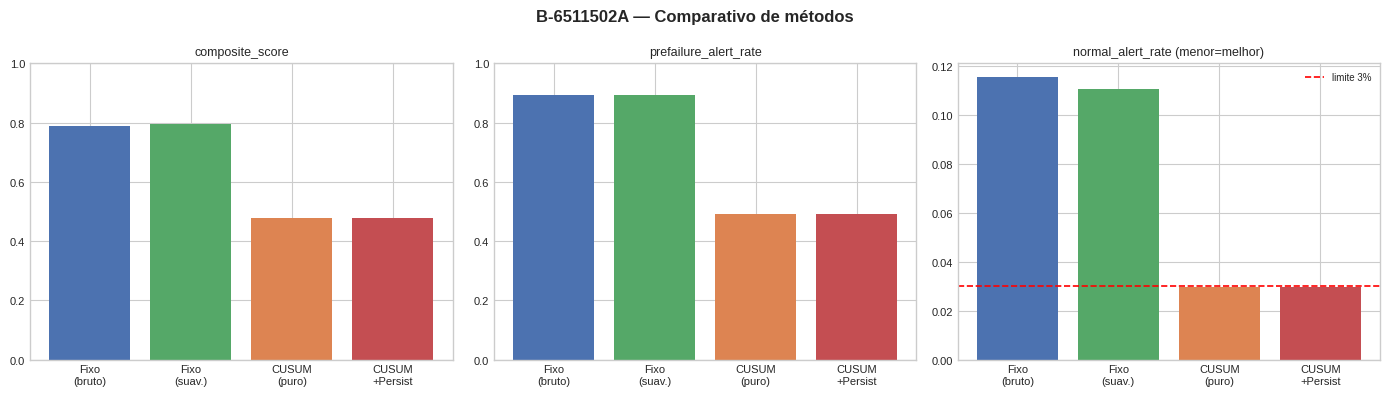

In [32]:
automl_art = task.artifacts.get('automl_results')
if automl_art is not None:
    automl_df       = automl_art.get()
    fixed_threshold = float(automl_df.iloc[0]['threshold'])
    fixed_model     = str(automl_df.iloc[0].get('model', '?'))

    # Threshold fixo sobre sinal bruto
    alarms_fixed_raw    = x_raw > fixed_threshold
    m_fixed_raw         = failure_metrics(alarms_fixed_raw, ts, EVENT_TS, PREFAILURE_DAYS, NORMAL_END_DAYS)

    # Threshold fixo sobre sinal suavizado
    alarms_fixed_smooth = x > fixed_threshold
    m_fixed_smooth      = failure_metrics(alarms_fixed_smooth, ts, EVENT_TS, PREFAILURE_DAYS, NORMAL_END_DAYS)

    # CUSUM puro (sem persistence filter)
    m_cusum_raw = failure_metrics(alarms_cusum, ts, EVENT_TS, PREFAILURE_DAYS, NORMAL_END_DAYS)

    comparison = pd.DataFrame([
        {'metodo': f'Threshold fixo — bruto ({fixed_model}, thr={fixed_threshold:.4f})',
         **m_fixed_raw},
        {'metodo': f'Threshold fixo — suavizado ({SMOOTH_METHOD} w={SMOOTH_WINDOW})',
         **m_fixed_smooth},
        {'metodo': f'CUSUM puro (k={BEST_K}σ, h={BEST_H}σ) — sem persist',
         **m_cusum_raw},
        {'metodo': f'CUSUM + Persist {BEST_PK}/{BEST_PN} (k={BEST_K}σ, h={BEST_H}σ)',
         **m_best},
    ])

    display(comparison.style.format({
        'composite_score': '{:.4f}',
        'prefailure_alert_rate': '{:.2%}',
        'normal_alert_rate': '{:.2%}',
        'discrimination_ratio': '{:.2f}',
        'n_alarms_total': '{:,}',
    }).background_gradient(subset=['composite_score'], cmap='Greens'))

    # Bar chart 4 métodos × 3 métricas
    fig, axes = plt.subplots(1, 3, figsize=(FIGSIZE_WIDTH, 4))
    labels = ['Fixo\n(bruto)', 'Fixo\n(suav.)', 'CUSUM\n(puro)', f'CUSUM\n+Persist']
    colors = ['#4c72b0', '#55a868', '#dd8452', '#c44e52']
    metrics_keys = [
        ('composite_score',       'composite_score',                 (0, 1)),
        ('prefailure_alert_rate', 'prefailure_alert_rate',           (0, 1)),
        ('normal_alert_rate',     'normal_alert_rate (menor=melhor)', None),
    ]
    for ax, (col, title_, ylim) in zip(axes, metrics_keys):
        vals = comparison[col].tolist()
        bars = ax.bar(labels, vals, color=colors)
        ax.set_title(title_, fontsize=9)
        if ylim:
            ax.set_ylim(*ylim)
        # Linha de constraint no painel normal_rate
        if col == 'normal_alert_rate':
            ax.axhline(MAX_NORMAL_RATE, color='red', linestyle='--',
                       linewidth=1.2, label=f'limite {MAX_NORMAL_RATE:.0%}')
            ax.legend(fontsize=7)
        ax.tick_params(labelsize=8)
    fig.suptitle(f'{EQUIPMENT_ID} — Comparativo de métodos', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('artifact automl_results nao disponivel.')

## Primeiro alerta — antecedência à falha

In [33]:
def first_alarm_before(alarms_arr, ts_arr, event_ts):
    pre  = ts_arr[ts_arr < event_ts]
    al   = alarms_arr[:len(pre)]
    hits = pre[al]
    if len(hits) == 0:
        return None, None
    first = hits[0]
    return first, event_ts - first


_no_alarms = np.zeros(len(ts), dtype=bool)

candidates = [
    ('Threshold fixo (bruto)',           alarms_fixed_raw    if automl_art is not None else _no_alarms),
    ('Threshold fixo (suavizado)',        alarms_fixed_smooth if automl_art is not None else _no_alarms),
    (f'CUSUM puro (k={BEST_K}, h={BEST_H})',              alarms_cusum),
    (f'CUSUM + Persist {BEST_PK}/{BEST_PN}',              alarms_best),
]

print(f'{"Método":<45}  {"Primeiro alerta":>22}  {"Antecedência":>15}')
print('-' * 87)
for label, alarms_arr in candidates:
    first_ts, delta = first_alarm_before(alarms_arr, ts, EVENT_TS)
    if first_ts is not None:
        print(f'{label:<45}  {str(first_ts):>22}  {delta.days:>4}d {delta.seconds//3600:>2}h antes da falha')
    else:
        print(f'{label:<45}  {"—":>22}  {"nenhum alerta":>15}')

Método                                                Primeiro alerta     Antecedência
---------------------------------------------------------------------------------------
Threshold fixo (bruto)                            2022-06-11 18:45:00   337d  5h antes da falha
Threshold fixo (suavizado)                        2022-06-24 19:35:00   324d  4h antes da falha
CUSUM puro (k=0.75, h=1.0)                        2022-07-02 02:55:00   316d 21h antes da falha
CUSUM + Persist 1/1                               2022-07-02 02:55:00   316d 21h antes da falha
